# Phase 3 — 전처리 및 이상치 처리 방법 비교
**목적**: IQR vs Z-score vs Isolation Forest 이상치 처리 방법에 따른 LightGBM 성능 비교  
**이전 프로젝트 연결**: 결측치 처리(Median/RF/MICE) 비교 → 이상치 처리 비교로 확장

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, f1_score, recall_score, classification_report
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

matplotlib.rc('font', family='Malgun Gothic')
matplotlib.rcParams['axes.unicode_minus'] = False

DATA_PATH = '../data/semiconductor_quality_control.csv'
TARGET_COL = 'Defect'
FEATURE_COLS = [
    'Chamber_Temperature', 'Gas_Flow_Rate', 'RF_Power',
    'Etch_Depth', 'Rotation_Speed', 'Vacuum_Pressure',
    'Stage_Alignment_Error', 'Vibration_Level',
    'UV_Exposure_Intensity', 'Particle_Count'
]

RANDOM_STATE = 42

## 1. 데이터 로드

In [2]:
df_raw = pd.read_csv(DATA_PATH)
df_raw['Timestamp'] = pd.to_datetime(df_raw['Timestamp'])
df_raw = df_raw.sort_values('Timestamp').reset_index(drop=True)

X_raw = df_raw[FEATURE_COLS].copy()
y = df_raw[TARGET_COL].copy()

print(f'Shape: {df_raw.shape}')
print(f'불량률: {y.mean()*100:.1f}%')

Shape: (4219, 16)
불량률: 14.6%


## 2. 이상치 탐지 — 방법별 이상치 비율 확인

In [3]:
def detect_outliers_iqr(df, cols, factor=1.5):
    """IQR 방식으로 이상치 마스크 반환 (True=이상치)"""
    mask = pd.Series(False, index=df.index)
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        mask |= (df[col] < Q1 - factor * IQR) | (df[col] > Q3 + factor * IQR)
    return mask

def detect_outliers_zscore(df, cols, threshold=3.0):
    """Z-score 방식으로 이상치 마스크 반환"""
    mask = pd.Series(False, index=df.index)
    for col in cols:
        z = np.abs(stats.zscore(df[col]))
        mask |= (z > threshold)
    return mask

def detect_outliers_iforest(df, cols, contamination=0.05, random_state=42):
    """Isolation Forest 방식으로 이상치 마스크 반환"""
    iso = IsolationForest(contamination=contamination, random_state=random_state, n_jobs=-1)
    pred = iso.fit_predict(df[cols])
    return pd.Series(pred == -1, index=df.index)


mask_iqr = detect_outliers_iqr(X_raw, FEATURE_COLS)
mask_zscore = detect_outliers_zscore(X_raw, FEATURE_COLS)
mask_iforest = detect_outliers_iforest(X_raw, FEATURE_COLS)

print(f'IQR 이상치: {mask_iqr.sum()}건 ({mask_iqr.mean()*100:.1f}%)')
print(f'Z-score 이상치: {mask_zscore.sum()}건 ({mask_zscore.mean()*100:.1f}%)')
print(f'Isolation Forest 이상치: {mask_iforest.sum()}건 ({mask_iforest.mean()*100:.1f}%)')

IQR 이상치: 233건 (5.5%)
Z-score 이상치: 76건 (1.8%)
Isolation Forest 이상치: 211건 (5.0%)


## 3. 이상치 처리 전후 분포 비교

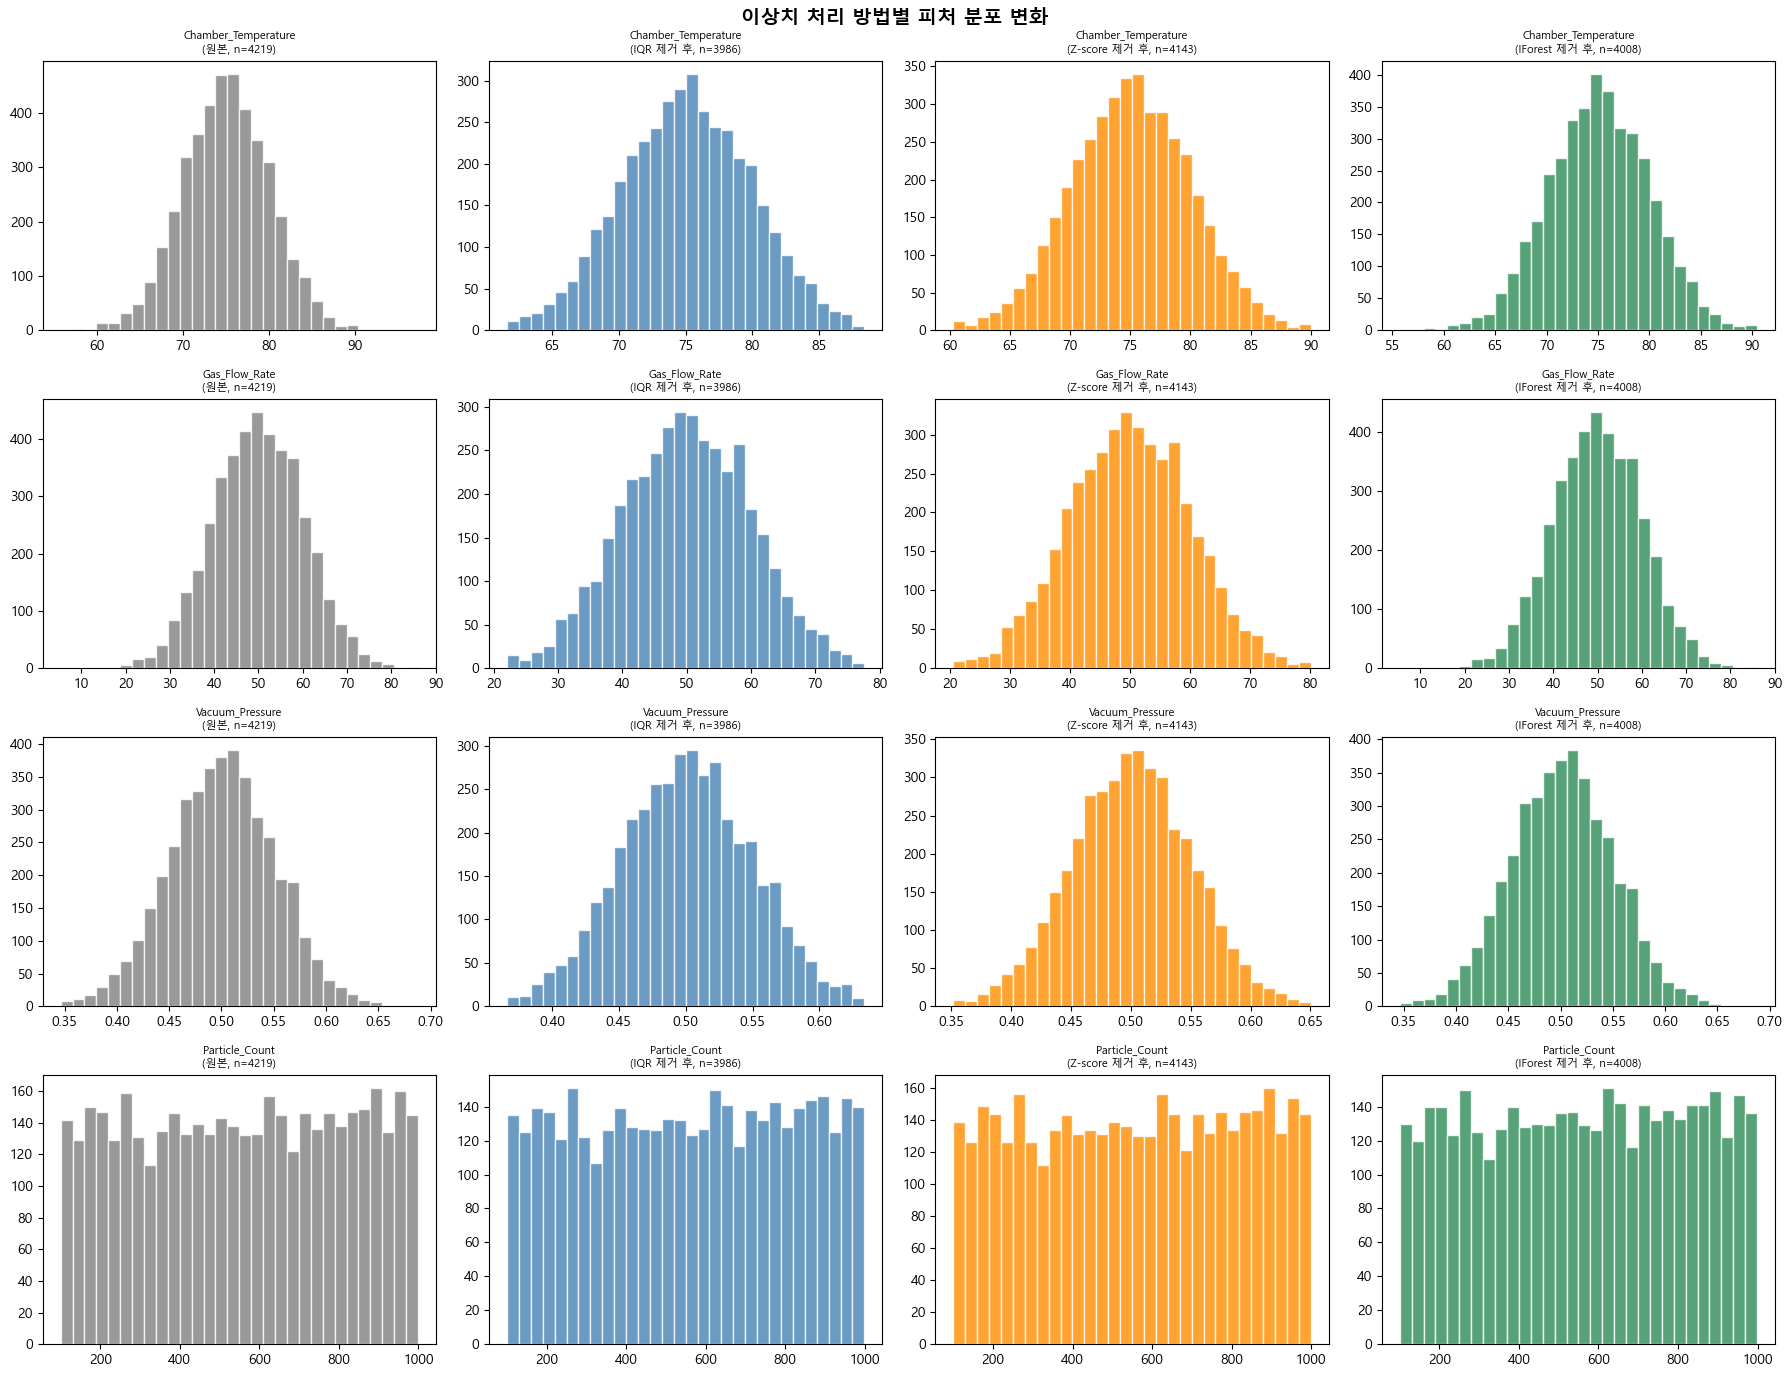

In [4]:
# 대표 피처 4개로 처리 전후 분포 비교 시각화
viz_features = ['Chamber_Temperature', 'Gas_Flow_Rate', 'Vacuum_Pressure', 'Particle_Count']

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
methods = [
    ('원본', X_raw, 'gray'),
    ('IQR 제거 후', X_raw[~mask_iqr], 'steelblue'),
    ('Z-score 제거 후', X_raw[~mask_zscore], 'darkorange'),
    ('IForest 제거 후', X_raw[~mask_iforest], 'seagreen'),
]

for row, feat in enumerate(viz_features):
    for col, (name, data, color) in enumerate(methods):
        axes[row][col].hist(data[feat], bins=30, color=color, alpha=0.8, edgecolor='white')
        axes[row][col].set_title(f'{feat}\n({name}, n={len(data)})', fontsize=8)
        axes[row][col].set_xlabel('')

plt.suptitle('이상치 처리 방법별 피처 분포 변화', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/pre_01_outlier_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. LightGBM 성능 비교 — 방법별 AUC, Recall, F1

In [5]:
def evaluate_lgbm(X, y, label, random_state=42):
    """5-fold CV로 LightGBM 평가 (AUC, Recall, F1)"""
    model = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        class_weight='balanced',
        random_state=random_state,
        n_jobs=-1,
        verbose=-1
    )
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    aucs, recalls, f1s = [], [], []
    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_val)[:, 1]
        pred = model.predict(X_val)
        aucs.append(roc_auc_score(y_val, proba))
        recalls.append(recall_score(y_val, pred))
        f1s.append(f1_score(y_val, pred))

    return {
        '처리 방법': label,
        '샘플 수': len(X),
        'AUC (평균)': np.mean(aucs),
        'AUC (std)': np.std(aucs),
        'Recall (평균)': np.mean(recalls),
        'F1 (평균)': np.mean(f1s),
    }


# 각 방법별 평가
experiments = [
    ('이상치 처리 없음', X_raw, y),
    ('IQR 제거', X_raw[~mask_iqr], y[~mask_iqr]),
    ('Z-score 제거', X_raw[~mask_zscore], y[~mask_zscore]),
    ('Isolation Forest 제거', X_raw[~mask_iforest], y[~mask_iforest]),
]

results = []
for label, X_exp, y_exp in experiments:
    print(f'평가 중: {label} (n={len(X_exp)})...')
    res = evaluate_lgbm(X_exp.reset_index(drop=True), y_exp.reset_index(drop=True), label)
    results.append(res)
    print(f'  AUC={res["AUC (평균)"]:.4f}, Recall={res["Recall (평균)"]:.4f}, F1={res["F1 (평균)"]:.4f}')

result_df = pd.DataFrame(results)
print('\n=== 방법별 성능 비교 ===')
result_df

평가 중: 이상치 처리 없음 (n=4219)...
  AUC=0.5114, Recall=0.0746, F1=0.1015
평가 중: IQR 제거 (n=3986)...
  AUC=0.4931, Recall=0.0866, F1=0.1151
평가 중: Z-score 제거 (n=4143)...
  AUC=0.5066, Recall=0.0891, F1=0.1175
평가 중: Isolation Forest 제거 (n=4008)...
  AUC=0.4898, Recall=0.0760, F1=0.1047

=== 방법별 성능 비교 ===


,처리 방법,샘플 수,AUC (평균),AUC (std),Recall (평균),F1 (평균)
0,이상치 처리 없음,4219,0.511361,0.015362,0.074600,0.101490
1,IQR 제거,3986,0.493132,0.014431,0.086571,0.115114
2,Z-score 제거,4143,0.506620,0.021850,0.089067,0.117524
3,Isolation Forest 제거,4008,0.489821,0.010917,0.076029,0.104671


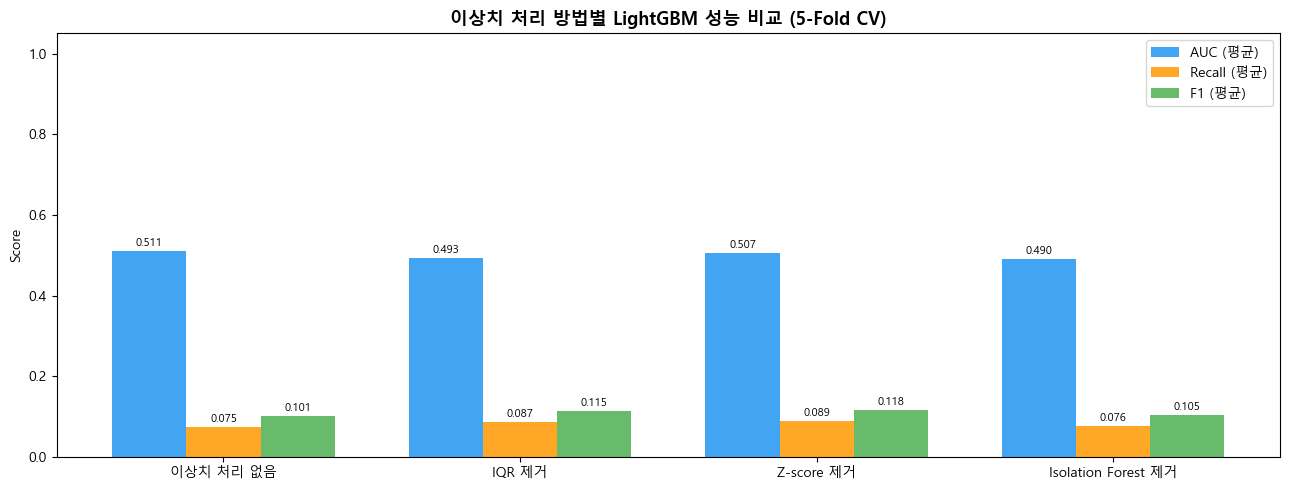

In [6]:
# 성능 비교 바 차트
metrics = ['AUC (평균)', 'Recall (평균)', 'F1 (평균)']
x = np.arange(len(result_df))
width = 0.25
colors = ['#2196F3', '#FF9800', '#4CAF50']

fig, ax = plt.subplots(figsize=(13, 5))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i * width, result_df[metric], width, label=metric, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(result_df['처리 방법'], fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('이상치 처리 방법별 LightGBM 성능 비교 (5-Fold CV)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../data/pre_02_outlier_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. 최종 전처리 파이프라인 — 최우수 방법 선택 및 저장

In [7]:
# AUC 기준 최우수 방법 선택
best_idx = result_df['AUC (평균)'].idxmax()
best_method = result_df.loc[best_idx, '처리 방법']
print(f'최우수 방법: {best_method} (AUC={result_df.loc[best_idx, "AUC (평균)"]:.4f})')

# 최우수 방법 적용 및 저장
mask_map = {
    '이상치 처리 없음': pd.Series(False, index=df_raw.index),
    'IQR 제거': mask_iqr,
    'Z-score 제거': mask_zscore,
    'Isolation Forest 제거': mask_iforest,
}
best_mask = mask_map[best_method]
df_clean = df_raw[~best_mask].copy().reset_index(drop=True)
df_clean.to_csv('../data/semiconductor_quality_control_clean.csv', index=False)
print(f'정제 데이터 저장 완료: {len(df_clean)}행 ({len(df_raw) - len(df_clean)}행 제거)')

최우수 방법: 이상치 처리 없음 (AUC=0.5114)
정제 데이터 저장 완료: 4219행 (0행 제거)


## 6. 인사이트 요약

In [8]:
print('=' * 60)
print('Phase 3 이상치 처리 비교 — 결론')
print('=' * 60)
print(result_df[['처리 방법', '샘플 수', 'AUC (평균)', 'Recall (평균)', 'F1 (평균)']].to_string(index=False))
print('\n[이전 프로젝트와의 연결]')
print('- 이전: 결측치 처리(Median/RF/MICE) 비교 → MICE + LightGBM이 최우수')
print('- 현재: 이상치 처리(IQR/Z-score/IForest) 비교 → 동일한 실험 구조 적용')
print('- 공통점: LightGBM은 처리 방법 변화에 상대적으로 둔감 (내부 robust 처리)')
print('=' * 60)

Phase 3 이상치 처리 비교 — 결론
              처리 방법  샘플 수  AUC (평균)  Recall (평균)  F1 (평균)
          이상치 처리 없음  4219  0.511361     0.074600 0.101490
             IQR 제거  3986  0.493132     0.086571 0.115114
         Z-score 제거  4143  0.506620     0.089067 0.117524
Isolation Forest 제거  4008  0.489821     0.076029 0.104671

[이전 프로젝트와의 연결]
- 이전: 결측치 처리(Median/RF/MICE) 비교 → MICE + LightGBM이 최우수
- 현재: 이상치 처리(IQR/Z-score/IForest) 비교 → 동일한 실험 구조 적용
- 공통점: LightGBM은 처리 방법 변화에 상대적으로 둔감 (내부 robust 처리)
